In [3]:
import pandas as pd

df = pd.read_csv("data/read.csv")

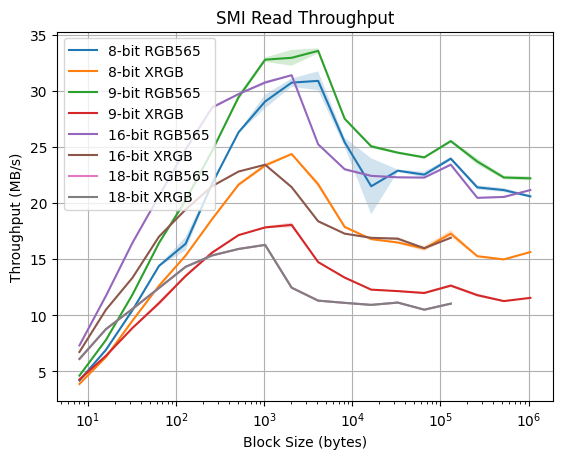

In [12]:
import matplotlib.pyplot as plt

plt.figure()

for key, group in df.groupby(["Width","Pack"]):

    group = group.sort_values("Block")

    label = f"{key[0]}-bit {key[1]}"

    x = group["Block"]
    y = group["MBps"]

    # convert time stddev → throughput stddev
    yerr = group["stdev_s"] / (group["avg_time_s"]**2)

    plt.plot(x, y, label=label)

    plt.fill_between(
        x,
        y - yerr,
        y + yerr,
        alpha=0.2
    )

plt.xscale("log")
plt.xlabel("Block Size (bytes)")
plt.ylabel("Throughput (MB/s)")
plt.title("SMI Read Throughput")
plt.legend()
plt.grid(True)

plt.show()